# Aula 00 — Aquisição da imagem CBERS-4A/WPM via STAC

Buscar, escolher, pré-visualizar e **exportar** as bandas do
CBERS-4A/WPM a partir do STAC do INPE (Brazil Data Cube), coleção
**`CB4A-WPM-L4-DN-1`**. Ao final, os GeoTIFFs ficam em `data/raw`,
prontos para a Aula 01 (correção TOA/BOA).

> Rode local com `pixi run lab` (recomendado) ou no Google Colab. A
> primeira célula de código cuida da instalação quando você está no
> Colab.

| asset   | banda | faixa espectral | resolução |
|---------|-------|-----------------|-----------|
| `BAND0` | PAN   | 0,45–0,90 µm    | 2 m       |
| `BAND1` | Blue  | 0,45–0,52 µm    | 8 m       |
| `BAND2` | Green | 0,52–0,59 µm    | 8 m       |
| `BAND3` | Red   | 0,63–0,69 µm    | 8 m       |
| `BAND4` | NIR   | 0,77–0,89 µm    | 8 m       |

`L4-DN` = ortorretificado, em **números digitais** (`int16`,
`nodata = 0`), sem correção atmosférica.

**Duas particularidades desta coleção:** (1) não há metadado de nuvem —
escolhemos a cena pela miniatura e por um diagnóstico calculado na
própria AOI; (2) os arquivos não são COG, então o custo do recorte
cresce com a **altura** da AOI. Comece com uma AOI pequena (5–10 km).

In [1]:
# Detecta o ambiente. No Colab, instala as bibliotecas na sessao.
# Localmente (pixi), nao faz nada: o ambiente ja tem tudo.
import sys

NO_COLAB = "google.colab" in sys.modules
if NO_COLAB:
    !pip install -q pystac-client rasterio pandas matplotlib shapely pyproj requests pillow folium


## 0. Configuração e imports

In [2]:
import os

# ajustes de GDAL para leitura remota (defina ANTES de importar o rasterio)
os.environ.setdefault("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")  # evita listar o diretório remoto
os.environ.setdefault("GDAL_HTTP_MAX_RETRY", "5")                   # a API do INPE às vezes derruba a conexão
os.environ.setdefault("GDAL_HTTP_RETRY_DELAY", "2")
os.environ.setdefault("GDAL_CACHEMAX", "512")                       # MB de cache de blocos

from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import requests
from pystac_client import Client
from pyproj import Transformer
from rasterio.windows import Window, from_bounds
from rasterio.windows import transform as window_transform

STAC_URL = "https://data.inpe.br/bdc/stac/v1/"
COLLECTION = "CB4A-WPM-L4-DN-1"

# asset do STAC -> apelido usado nos arquivos de saída
BANDAS = {
    "BAND1": "blue",
    "BAND2": "green",
    "BAND3": "red",
    "BAND4": "nir",
    "BAND0": "pan",
}

# Local (pixi): cai direto na pasta que a Aula 01 le.
# No Colab, troque por um caminho no seu Drive (apos montar o Drive),
# ex.: OUTPUT_DIR = "/content/drive/MyDrive/geoproc/data/raw"
OUTPUT_DIR = "data/raw"
os.makedirs(OUTPUT_DIR, exist_ok=True)

client = Client.open(STAC_URL)
client

<Client id=INPE>
 
 
 
 
 
 
 
 
 type 
 "Catalog" 
 
 
 
 
 
 
 
 id 
 "INPE" 
 
 
 
 
 
 
 
 stac_version 
 "1.1.0" 
 
 
 
 
 
 
 
 description 
 "This is the landing page for the INPE STAC server. The SpatioTemporal Asset Catalogs (STAC) provide a standardized way to expose collections of spatial temporal data. Here you will find collections of data provided by projects and areas of INPE." 
 
 
 
 
 
 
 links [] 85 items 
 
 
 
 
 
 
 0 
 
 
 
 
 
 rel 
 "root" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "INPE STAC Server" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 1 
 
 
 
 
 
 rel 
 "self" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 2 
 
 
 
 
 
 rel 
 "service-doc" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/docs" 
 
 
 
 
 
 
 
 type 
 "text/html" 
 
 
 
 
 
 
 
 title 
 "API documentation in HTML" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 3 
 
 
 
 
 
 rel 
 "conformance" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/conformance" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "OGC API conformance classes implemented by the server" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 4 
 
 
 
 
 
 rel 
 "data" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "Information about image collections" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 5 
 
 
 
 
 
 rel 
 "search" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/search" 
 
 
 
 
 
 
 
 type 
 "application/geo+json" 
 
 
 
 
 
 
 
 title 
 "STAC-Search endpoint" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 6 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/S2-16D-2" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "Sentinel-2/MSI - Level-2A - Data Cube - LCF 16 days" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 7 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/prec_merge_hourly-1" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "MERGE - Hourly Gridded Precipitation over South America" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 8 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/mosaic-cbers4a-paraiba-3m-1" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "CBERS-4A/WFI 3M Paraíba State Mosaic" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 9 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/CB4-MUX-L4-SR-1" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "CBERS-4/MUX - Level-4-SR - Cloud Optimized GeoTIFF" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 10 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/mosaic-landsat-sp-6m-1" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "Landsat 6M São Paulo State Mosaic" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 11 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/mosaic-s2-paraiba-3m-1" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "S2 3M Paraiba State Mosaic" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 12 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/mosaic-s2-yanomami_territory-6m-1" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "S2 6M Yanomami Indigenous Territory Mosaic" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 13 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/modisa-ocsmart-rrs-monthly-1" 
 
 
 
 
 
 
 
 type 
 "application/json" 
 
 
 
 
 
 
 
 title 
 "MODIS-Aqua Monthly Rrs - OC-SMART AC" 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 14 
 
 
 
 
 
 rel 
 "child" 
 
 
 
 
 
 
 
 href 
 "https://data.inpe.br/bdc/stac/v1/collections/RESOURCESAT1_AWIFS_L2_DN-1" 
 
 
 
 

## 1. Definindo a AOI

Duas opções: um **bbox** manual (mais simples) ou a geometria de um
**município** via `geobr`. Use o [bbox
finder](https://rodostoteknoloji.com/online-tools/bbox-tool-en.html)
para pegar as coordenadas.

O `bbox` é sempre `[oeste, sul, leste, norte]` em graus (**EPSG:4326**).

Comece pequeno. Como os arquivos não são COG, o custo da leitura cresce
com a **altura** da AOI: um recorte de ~0,04° (≈ 4 km) resolve para
experimentar; depois você aumenta.

In [3]:
# ---- opção A: bbox na mão ----
AOI_BBOX = [-47.596712, -22.467523, -47.495068, -22.374216]
AOI_NOME = "rio_claro"

# # ---- opção B: município inteiro via geobr (descomente — cuidado, fica bem mais lento) ----
# import geobr
# import unicodedata
# muni = geobr.read_conservation_units(date=202503)
# print(muni.nome_uc)
# termo = normalizar("cipó")

# selecionadas = muni[
#       muni["nome_uc"].map(normalizar).str.contains(termo, na=False, regex=False)
# ]

# if selecionadas.empty:
#       raise ValueError("Nenhuma unidade de conservação contendo 'cipó' foi encontrada.")

# alvo = selecionadas.iloc[0]
# nome_alvo = alvo["nome_uc"]

# AOI_BBOX = list(alvo.geometry.bounds)
# AOI_NOME = "serra_do_cipo"

# print(f"Unidade selecionada: {nome_alvo}")
# AOI_BBOX = list(alvo.geometry.bounds)
# AOI_NOME = "rio_claro"

largura_km = (AOI_BBOX[2] - AOI_BBOX[0]) * 111 * np.cos(np.radians(AOI_BBOX[1]))
altura_km = (AOI_BBOX[3] - AOI_BBOX[1]) * 111
print(f"AOI: {AOI_BBOX}")
print(f"tamanho aproximado: {largura_km:.1f} x {altura_km:.1f} km")
print(f"pixels estimados: MS {largura_km * 125:.0f} x {altura_km * 125:.0f} | "
      f"PAN {largura_km * 500:.0f} x {altura_km * 500:.0f}")

AOI: [-47.596712, -22.467523, -47.495068, -22.374216]
tamanho aproximado: 10.4 x 10.4 km
pixels estimados: MS 1303 x 1295 | PAN 5213 x 5179

In [4]:
# visualização rápida da AOI (opcional)
import folium
from shapely.geometry import box

m = folium.Map()
folium.GeoJson(box(*AOI_BBOX).__geo_interface__,
               style_function=lambda x: {"fillColor": "none", "color": "red", "weight": 3}).add_to(m)
m.fit_bounds([[AOI_BBOX[1], AOI_BBOX[0]], [AOI_BBOX[3], AOI_BBOX[2]]])
m

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap-glyphicons.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_1ad311035a8ced5713901f763d119a3f {
 position: relative;
 width: 100.0%;
 height: 100.0%;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>

 <style>html, body {
 width: 100%;
 height: 100%;
 margin: 0;
 padding: 0;
 }
 </style>

 <style>#map {
 position:absolute;
 top:0;
 bottom:0;
 right:0;
 left:0;
 }
 </style>

 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>

 
</head>
<body>
 
 
 <div class="folium-map" id="map_1ad311035a8ced5713901f763d119a3f" ></div>
 
</body>
<script>
 
 
 var map_1ad311035a8ced5713901f763d119a3f = L.map(
 "map_1ad311035a8ced5713901f763d119a3f",
 {
 center: [0.0, 0.0],
 crs: L.CRS.EPSG3857,
 ...{
 "zoom": 1,
 "zoomControl": true,
 "preferCanvas": false,
}

 }
 );

 

 
 
 var tile_layer_2de7a052ccbfefa77bf2d1d10d79c813 = L.tileLayer(
 "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
 {
 "minZoom": 0,
 "maxZoom": 19,
 "maxNativeZoom": 19,
 "noWrap": false,
 "attribution": "\u0026copy; \u003ca href=\"https://www.openstreetmap.org/copyright\"\u003eOpenStreetMap\u003c/a\u003e contributors",
 "subdomains": "abc",
 "detectRetina": false,
 "tms": false,
 "opacity": 1,
}

 );
 
 
 tile_layer_2de7a052ccbfefa77bf2d1d10d79c813.addTo(map_1ad311035a8ced5713901f763d119a3f);
 
 
 function geo_json_f8e6f0d9bb03f501531c806fb187c44f_styler(feature) {
 switch(feature.id) {
 default:
 return {"color": "red", "fillColor": "none", "weight": 3};
 }
 }

 function geo_json_f8e6f0d9bb03f501531c806fb187c44f_onEachFeature(feature, layer) {

 layer.on({
 });
 };
 var geo_json_f8e6f0d9bb03f501531c806fb187c44f = L.geoJson(null, {
 onEachFeature: geo_json_f8e6f0d9bb03f501531c806fb187c44f_onEachFeature,
 
 style: geo_json_f8e6f0d9bb03f501531c806fb187c44f_styler,
 ...{
}
 });

 function geo_json_f8e6f0d9bb03f501531c806fb187c44f_add (data) {
 geo_json_f8e6f0d9bb03f501531c806fb187c44f
 .addData(data);
 }
 geo_json_f8e6f0d9bb03f501531c806fb187c44f_add({"features": [{"geometry": {"coordinates": [[[-47.495068, -22.467523], [-47.495068, -22.374216], [-47.596712, -22.374216], [-47.596712, -22.467523], [-47.495068, -22.467523]]], "type": "Polygon"}, "id": "0", "type": "Feature"}], "type": "FeatureCollection"});

 
 
 geo_json_f8e6f0d9bb03f501531c806fb187c44f.addTo(map_1ad311035a8ced5713901f763d119a3f);
 
 
 map_1ad311035a8ced5713901f763d119a3f.fitBounds(
 [[-22.467523, -47.596712], [-22.374216, -47.495068]],
 {}
 );
 
</script>
</html>" style="position:absolute;width:100%;height:100%;left:0;top:0;border:none !important;" allowfullscreen webkitallowfullscreen mozallowfullscreen>

## 2. Buscando as cenas

A busca por `bbox` retorna toda cena cujo **footprint** cruza a AOI —
inclusive as que só encostam em uma quina e cobrem a sua área só com
`nodata`. Por isso a tabela tem a coluna `orbita_ponto`: cenas de
órbitas diferentes cobrem partes diferentes (e, como veremos, chegam até
em **zonas UTM diferentes**).

In [5]:
def buscar_cenas(bbox, datetime_range, collection=COLLECTION, limite=None):
    """Busca cenas no STAC e devolve (lista_de_items, DataFrame com o resumo)."""
    busca = client.search(
        collections=[collection],
        bbox=bbox,
        datetime=datetime_range,
        max_items=limite,
    )
    items = list(busca.items())

    linhas = []
    for i, item in enumerate(items):
        props = item.properties
        linhas.append({
            "idx": i,
            "id": item.id,
            "data": str(props.get("datetime", ""))[:10],
            # nesta coleção vem sempre None; em CB4-MUX-L4-SR-1, por exemplo, vem preenchido
            "nuvens_meta_%": props.get("eo:cloud_cover"),
            "orbita_ponto": f"{props.get('path', '?')}_{props.get('row', '?')}",
            "bandas": sum(1 for k in BANDAS if k in item.assets),
        })

    return items, pd.DataFrame(linhas)


items, df = buscar_cenas(AOI_BBOX, "2025-01-01/2026-09-03")
print(f"{len(items)} cenas encontradas\n")
df

9 cenas encontradas


Repare que `nuvens_meta_%` está toda vazia — é o problema descrito lá em
cima. Vamos resolver isso de outro jeito.

## 3. Escolhendo no olho: as miniaturas

Cada item traz um asset `thumbnail`: um PNG leve da cena inteira. É a
forma mais rápida de ver se a cena está limpa e se ela realmente cobre a
sua região.

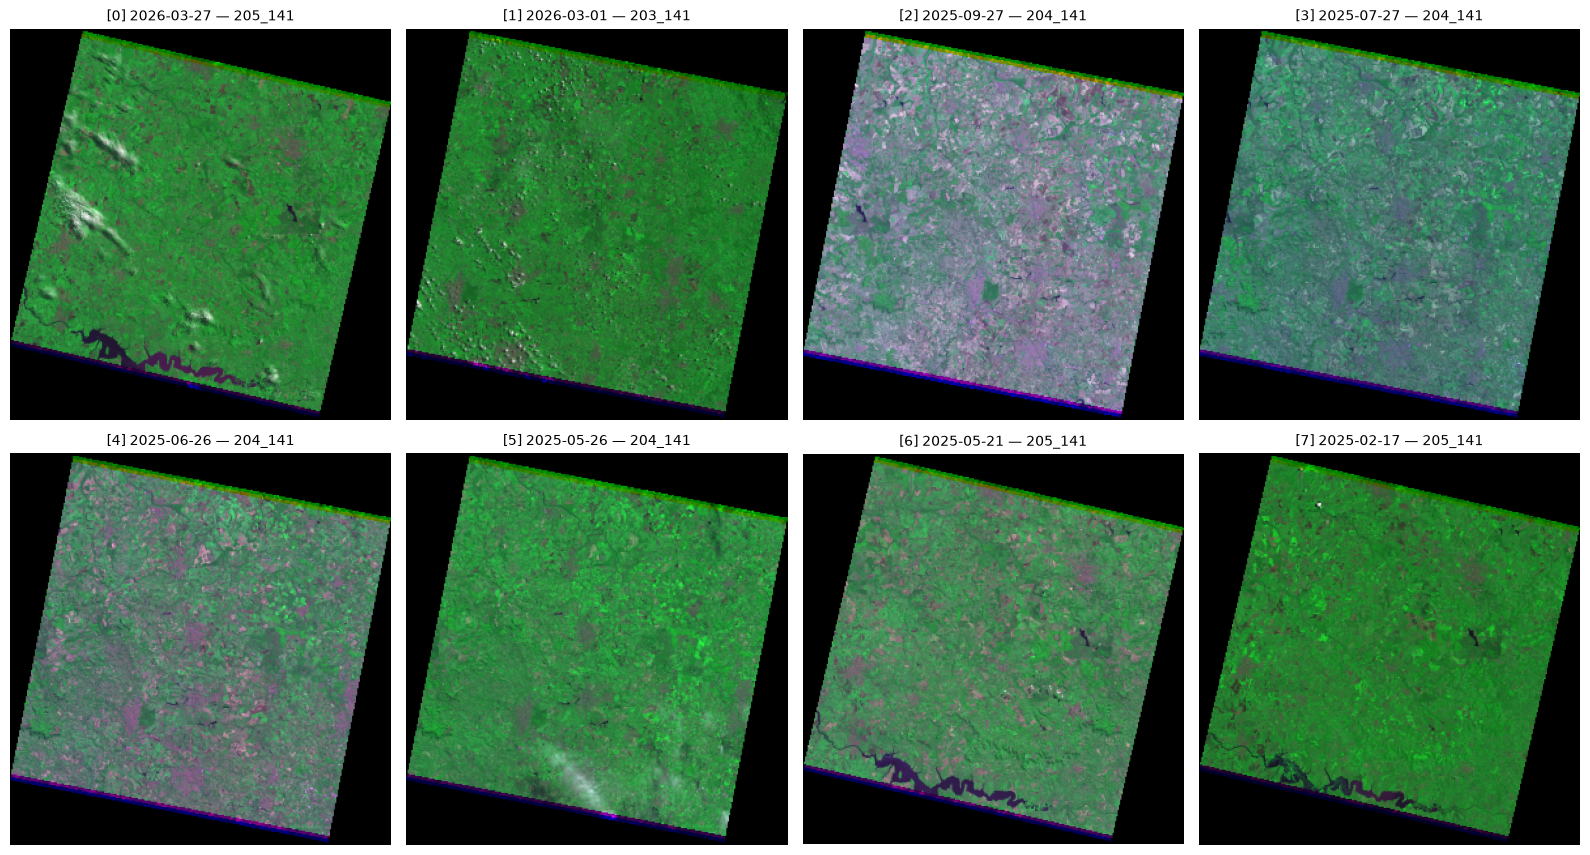

In [6]:
def mostrar_thumbnails(items, df, n=8, colunas=4):
    """Mostra as miniaturas das primeiras n cenas do DataFrame."""
    from PIL import Image

    subset = df.head(n)
    linhas = int(np.ceil(len(subset) / colunas))
    fig, axes = plt.subplots(linhas, colunas, figsize=(4 * colunas, 4.4 * linhas))
    axes = np.atleast_1d(axes).ravel()

    for ax, (_, row) in zip(axes, subset.iterrows()):
        item = items[int(row["idx"])]
        ax.axis("off")
        ax.set_title(f"[{row['idx']}] {row['data']} — {row['orbita_ponto']}", fontsize=10)

        thumb = item.assets.get("thumbnail")
        if thumb is None:
            ax.text(0.5, 0.5, "sem thumbnail", ha="center", va="center")
            continue
        try:
            resp = requests.get(thumb.href, timeout=60)
            resp.raise_for_status()
            ax.imshow(Image.open(BytesIO(resp.content)))
        except Exception as erro:
            ax.text(0.5, 0.5, f"erro: {erro}", ha="center", va="center", fontsize=8, wrap=True)

    for ax in axes[len(subset):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


mostrar_thumbnails(items, df, n=8)

## 4. Lendo só a AOI

Daqui em diante nada é lido por inteiro: a cena PAN tem 3,2 gigapixels e
tudo o que interessa é o retângulo da AOI. As três funções abaixo fazem
esse recorte, e são usadas também na pré-visualização (seção 6) e na
exportação (seção 7) — **rode esta seção mesmo que você já saiba qual
cena quer**.

- `reprojetar_bounds` leva o bbox de graus para o CRS da cena;
- `janela_da_aoi` converte esses limites numa janela de pixels,
  calculada no `transform` de **cada arquivo** — a PAN tem grade de 2 m
  e as multiespectrais de 8 m, e cenas de órbitas diferentes podem até
  cair em zonas UTM diferentes;
- `ler_aoi` lê essa janela, opcionalmente decimada, para inspeção
  rápida.

In [7]:
def reprojetar_bounds(bounds, de="EPSG:4326", para=None):
    """Converte um bbox de um CRS para outro."""
    transformer = Transformer.from_crs(de, para, always_xy=True)
    minx, miny = transformer.transform(bounds[0], bounds[1])
    maxx, maxy = transformer.transform(bounds[2], bounds[3])
    return (minx, miny, maxx, maxy)


def janela_da_aoi(src, bbox):
    """Janela (em pixels) do dataset correspondente ao bbox em EPSG:4326, limitada à cena.

    Cada asset é aberto separadamente porque a PAN tem grade de 2 m e as multiespectrais de 8 m —
    e cenas de órbitas diferentes podem até estar em zonas UTM diferentes. A janela precisa ser
    calculada no `transform` de cada arquivo.
    """
    bounds = reprojetar_bounds(bbox, "EPSG:4326", src.crs)
    janela = from_bounds(*bounds, src.transform).round_offsets().round_lengths()

    # recorta a janela ao tamanho real da cena (a AOI pode extrapolar as bordas)
    col_off = max(0, int(janela.col_off))
    row_off = max(0, int(janela.row_off))
    col_fim = min(src.width, int(janela.col_off + janela.width))
    row_fim = min(src.height, int(janela.row_off + janela.height))
    if col_fim <= col_off or row_fim <= row_off:
        raise ValueError("A AOI não intersecta o retângulo desta cena.")
    return Window(col_off, row_off, col_fim - col_off, row_fim - row_off)


def ler_aoi(href, bbox, max_dim=None, masked=True):
    """Lê a AOI de um asset. Com max_dim, faz leitura decimada (economiza RAM, não rede).

    Retorna (array, transform, crs).
    """
    with rasterio.open(href) as src:
        janela = janela_da_aoi(src, bbox)
        altura, largura = int(janela.height), int(janela.width)

        if max_dim and max(altura, largura) > max_dim:
            fator = max(altura, largura) / max_dim
            out_shape = (max(1, int(altura / fator)), max(1, int(largura / fator)))
        else:
            out_shape = (altura, largura)

        dados = src.read(1, window=janela, out_shape=out_shape, masked=masked)
        # o transform precisa acompanhar a decimação
        transform = window_transform(janela, src.transform) * rasterio.Affine.scale(
            largura / out_shape[1], altura / out_shape[0]
        )
        return dados, transform, src.crs

### A cena cobre mesmo a sua AOI?

Vale responder isso antes de baixar centenas de megabytes. A busca por
`bbox` usa o **contorno** da cena, e é comum uma cena aparecer no
resultado com **0% de cobertura real**: o retângulo dela cruza a AOI,
mas ali só tem `nodata`. A conta abaixo lê uma versão minúscula do azul
(150 px de lado) e mede quantos por cento da AOI têm dado válido.

É só isso que este passo faz. Não tento estimar nuvem por limiar de
brilho aqui: testei e o número engana — a cena que uso no curso tem
nuvem de sobra para a Aula 02, e a heurística lhe dava 0,2%. **Nuvem
quem julga é você**, na miniatura da seção 3 e na pré-visualização da
seção 6; e, de verdade, a Aula 02, com um modelo treinado exatamente
para isso.

In [8]:
def cobertura_da_aoi(item, bbox, max_dim=150):
    """% da AOI com dado válido nesta cena, a partir de uma leitura reduzida do azul."""
    azul, *_ = ler_aoi(item.assets["BAND1"].href, bbox, max_dim=max_dim)
    validos = np.ma.filled(azul.astype("float32"), 0) > 0
    return round(100 * validos.sum() / validos.size, 1)


linhas = []
for _, row in df.head(6).iterrows():
    idx = int(row["idx"])
    try:
        pct = cobertura_da_aoi(items[idx], AOI_BBOX)
    except Exception as erro:
        pct = np.nan
        print(f"[{idx}] falhou: {type(erro).__name__}: {erro}")
    linhas.append({"idx": idx, "cobertura_aoi_%": pct})

df_cob = df.merge(pd.DataFrame(linhas), on="idx", how="left")
df_cob[["idx", "id", "data", "orbita_ponto", "cobertura_aoi_%"]]

## 5. Escolhendo a cena

Pegue o número da coluna `idx` da cena que você quer e coloque em
`ESCOLHA`. Dois critérios:

1.  **`cobertura_aoi_%` acima de 95** — abaixo disso a cena não cobre a
    sua área de verdade;
2.  **nuvem sobre uma parte da AOI**, olhando a miniatura da seção 3.

O segundo critério vai contra o instinto, e é de propósito. Normalmente
você quer a cena mais limpa possível; mas nas Aulas 02 e 03 a gente
detecta nuvem e preenche o buraco com Sentinel-2 super-resolvido, e para
isso **precisa de nuvem**. Não precisa ser muita: uma mancha pequena
sobre a área urbana já dá o que fazer nas duas aulas seguintes.

A cena de referência do curso é a **`CBERS_4A_WPM_20260301_203_141_L4`**
(01/03/2026) — é a que aparece nos vídeos e a que os notebooks das aulas
seguintes usam por padrão. Se você escolher outra, ou estiver em outra
área, **anote o `id`**: as Aulas 01, 02 e 03 pedem esse identificador na
célula de configuração.

In [9]:
ESCOLHA = 1  # <-- troque aqui pelo "idx" da cena desejada
             #     (a cena de referência do curso tem nuvem sobre parte da AOI)

item = items[ESCOLHA]
print("id:     ", item.id)
print("data:   ", item.properties.get("datetime"))
print("órbita: ", item.properties.get("path"), "/", item.properties.get("row"))
print("assets: ", [k for k in item.assets if not k.endswith("_xml")])

id:      CBERS_4A_WPM_20260301_203_141_L4
data:    2026-03-01T13:03:19.000000Z
órbita:  203 / 141
assets:  ['BAND0', 'BAND1', 'BAND2', 'BAND3', 'BAND4', 'thumbnail']

## 6. Pré-visualização em RGB

Contraste por **percentil** (2%–98%): mais robusto que min/max, porque
um pixel saturado (nuvem) ou uma sombra não achatam a imagem inteira. O
`nodata = 0` é descartado antes de calcular os percentis, senão a borda
preta puxaria o contraste toda vez que a AOI encosta no limite da cena.

In [10]:
def stretch(array, low_pct=2, high_pct=98):
    """Normaliza um array para 0–1 usando contraste por percentil, ignorando nodata (0)."""
    dados = np.ma.filled(array.astype("float64"), np.nan)
    validos = dados[np.isfinite(dados) & (dados > 0)]
    if validos.size == 0:
        return np.zeros_like(dados)
    p_lo, p_hi = np.percentile(validos, [low_pct, high_pct])
    if p_hi <= p_lo:
        p_hi = p_lo + 1
    return np.clip((dados - p_lo) / (p_hi - p_lo), 0, 1)


def preview_rgb(item, bbox, max_dim=800, bandas=("BAND3", "BAND2", "BAND1"), titulo=None):
    """Monta e plota uma composição de 3 bandas da AOI (padrão: R, G, B)."""
    canais = [ler_aoi(item.assets[b].href, bbox, max_dim=max_dim)[0] for b in bandas]
    rgb = np.dstack([stretch(c) for c in canais])

    plt.figure(figsize=(9, 9))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(titulo or f"{item.id}\n{str(item.properties.get('datetime'))[:10]}")
    plt.tight_layout()
    plt.show()
    return rgb


rgb = preview_rgb(item, AOI_BBOX)

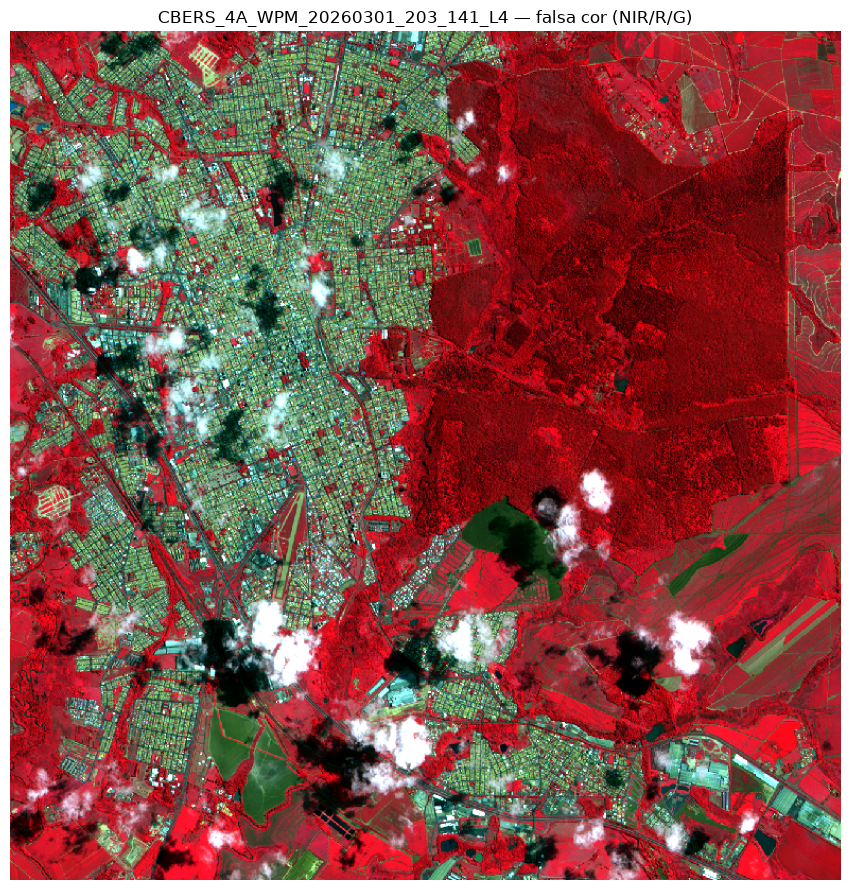

shape do preview: (800, 783, 3)

In [11]:
# falsa cor (NIR, R, G): vegetação em vermelho — bom para conferir a cena antes de exportar
_ = preview_rgb(item, AOI_BBOX, bandas=("BAND4", "BAND3", "BAND2"),
                titulo=f"{item.id} — falsa cor (NIR/R/G)")

**Gostou da cena?** Se não, volte na célula do `ESCOLHA`, troque o `idx`
e rode de novo. Quando estiver satisfeito, siga para a exportação.

## 7. Exportando as bandas recortadas

Agora lemos em **resolução total** (sem `max_dim`) e gravamos em
GeoTIFF, preservando:

- o `dtype` original (`int16`, números digitais) e o `nodata = 0` — sem
  perder informação radiométrica;
- o CRS e o `transform` **da janela** recortada, então o arquivo abre
  georreferenciado no QGIS;
- compressão `deflate` e *tiling* — ou seja, a saída fica mais bem
  organizada que a entrada.

Saem 5 GeoTIFFs, nomeados com o **asset do INPE** (`BAND0` = PAN,
`BAND1` = blue, `BAND2` = green, `BAND3` = red, `BAND4` = nir) — assim o
recorte carrega o mesmo nome de banda do produto original. Ao lado de
cada um vem o **XML de metadados** daquela banda (asset `BANDn_xml` do
STAC): ângulos de visada e solar, órbita/ponto, data de passagem e
parâmetros de processamento. São poucos KB cada e descrevem a **cena
inteira** — não são recortados junto com o raster, mas valem como
procedência do recorte. Passe `com_xml=False` se não quiser baixá-los.

A PAN é a mais demorada de longe: são 4x mais linhas e 4x mais colunas
que a MS. Numa AOI de 4 x 4 km, medindo de verdade: cada banda MS (506 x
563 px) leva ~2 s, e a PAN (2022 x 2251 px) leva ~45 s. Escale a partir
daí — e lembre que o custo acompanha a **altura** da AOI.

> **CRS da saída:** o arquivo herda a zona UTM da cena de origem. Se
> você exportar cenas de órbitas diferentes da mesma AOI (ex.: 204 em
> EPSG:32723 e 205 em EPSG:32722), elas **não** vão estar no mesmo CRS —
> reprojete antes de comparar.

In [12]:
def exportar_banda(href, bbox, caminho_saida):
    """Lê a AOI em resolução total e salva como GeoTIFF."""
    with rasterio.open(href) as src:
        janela = janela_da_aoi(src, bbox)
        dados = src.read(1, window=janela)
        altura, largura = int(janela.height), int(janela.width)

        perfil = src.profile.copy()
        perfil.update(
            driver="GTiff",
            height=altura,
            width=largura,
            count=1,
            transform=window_transform(janela, src.transform),
            compress="deflate",
            predictor=2,
        )
        # tiling só faz sentido se o recorte for maior que o bloco
        if altura >= 512 and largura >= 512:
            perfil.update(tiled=True, blockxsize=512, blockysize=512)
        else:
            perfil.update(tiled=False)
            perfil.pop("blockxsize", None)
            perfil.pop("blockysize", None)

    with rasterio.open(caminho_saida, "w", **perfil) as dst:
        dst.write(dados, 1)

    validos = 100 * np.count_nonzero(dados) / dados.size
    tamanho_mb = os.path.getsize(caminho_saida) / 1024**2
    print(f"  {os.path.basename(caminho_saida):55s} {dados.shape} {dados.dtype} "
          f"| {validos:5.1f}% válidos | {tamanho_mb:6.1f} MB")
    return caminho_saida


def exportar_xml(item, asset, caminho_saida):
    """Baixa o XML de metadados da banda (asset `<BANDA>_xml`, poucos KB).

    Atenção: o XML descreve a **cena inteira** (footprint, ângulos, órbita, data de
    processamento) — ele não é recortado junto com o raster. Guarde-o como procedência
    do recorte, não como descrição da AOI.
    """
    chave = f"{asset}_xml"
    if chave not in item.assets:
        print(f"  ! asset {chave} não existe nesta cena — pulando")
        return None

    resposta = requests.get(item.assets[chave].href, timeout=120)
    resposta.raise_for_status()
    with open(caminho_saida, "wb") as f:
        f.write(resposta.content)

    print(f"  {os.path.basename(caminho_saida):55s} "
          f"{len(resposta.content) / 1024:21.1f} KB de metadados")
    return caminho_saida


def exportar_cena(item, bbox, prefixo, output_dir=OUTPUT_DIR, bandas=BANDAS, com_xml=True):
    """Exporta todas as bandas da AOI (+ os XML de metadados). Retorna {asset: caminho}.

    Os arquivos saem com o nome do asset do INPE (`BAND0`..`BAND4`), e não com o apelido —
    assim o nome do recorte casa com o do produto original e com o XML que o acompanha.
    Use `BANDAS[asset]` quando precisar do apelido (`red`, `nir`, ...).
    """
    saidas = {}
    print(f"Exportando {item.id}:")
    for asset, apelido in bandas.items():
        if asset not in item.assets:
            print(f"  ! asset {asset} não existe nesta cena — pulando")
            continue
        base = os.path.join(output_dir, f"{prefixo}_{item.id}_{asset}")
        try:
            saidas[asset] = exportar_banda(item.assets[asset].href, bbox, base + ".tif")
        except Exception as erro:
            # a API do INPE derruba conexão de vez em quando; rode a célula de novo para o que faltou
            print(f"  ! falhou em {asset} ({apelido}): {type(erro).__name__}: {erro}")

        if com_xml:
            try:
                caminho_xml = exportar_xml(item, asset, base + ".xml")
                if caminho_xml:
                    saidas[f"{asset}_xml"] = caminho_xml
            except Exception as erro:
                print(f"  ! falhou no XML de {asset}: {type(erro).__name__}: {erro}")
    return saidas


arquivos = exportar_cena(item, AOI_BBOX, AOI_NOME)
arquivos

Exportando CBERS_4A_WPM_20260301_203_141_L4:
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND1.tif    (1314, 1287) int16 | 100.0% válidos |    1.6 MB
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND1.xml                     19.4 KB de metadados
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND2.tif    (1314, 1287) int16 | 100.0% válidos |    1.7 MB
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND2.xml                     19.4 KB de metadados
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND3.tif    (1314, 1287) int16 | 100.0% válidos |    1.8 MB
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND3.xml                     19.4 KB de metadados
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND4.tif    (1314, 1287) int16 | 100.0% válidos |    2.1 MB
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND4.xml                     19.4 KB de metadados
  rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND0.tif    (5257, 5146) int16 | 100.0% válidos |   27.0 MB
  rio_claro_CBERS_4A_WPM_20260301_203_141

{'BAND1': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND1.tif',
 'BAND1_xml': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND1.xml',
 'BAND2': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND2.tif',
 'BAND2_xml': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND2.xml',
 'BAND3': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND3.tif',
 'BAND3_xml': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND3.xml',
 'BAND4': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND4.tif',
 'BAND4_xml': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND4.xml',
 'BAND0': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND0.tif',
 'BAND0_xml': 'data/raw\\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_BAND0.xml'}

In [13]:
def empilhar(caminhos, caminho_saida, descricoes=None):
    """Empilha vários GeoTIFFs de mesma grade em um único arquivo multibanda."""
    with rasterio.open(caminhos[0]) as ref:
        perfil = ref.profile.copy()
    perfil.update(count=len(caminhos))

    with rasterio.open(caminho_saida, "w", **perfil) as dst:
        for i, caminho in enumerate(caminhos, start=1):
            with rasterio.open(caminho) as src:
                dst.write(src.read(1), i)
            if descricoes:
                dst.set_band_description(i, descricoes[i - 1])

    print(f"{caminho_saida}  ({len(caminhos)} bandas, "
          f"{os.path.getsize(caminho_saida) / 1024**2:.1f} MB)")
    return caminho_saida


# só as multiespectrais (8 m) — a PAN (BAND0, 2 m) tem outra grade e fica em arquivo separado
ordem = [a for a in ["BAND3", "BAND2", "BAND1", "BAND4"] if a in arquivos]  # R, G, B, NIR
stack_rgbn = empilhar(
    [arquivos[a] for a in ordem],
    os.path.join(OUTPUT_DIR, f"{AOI_NOME}_{item.id}_RGBN.tif"),
    # no arquivo empilhado a descrição da banda guarda o apelido: red, green, blue, nir
    descricoes=[BANDAS[a] for a in ordem],
)

data/raw\rio_claro_CBERS_4A_WPM_20260301_203_141_L4_RGBN.tif  (4 bandas, 7.4 MB)

## 8. Conferindo o que foi exportado

Abrindo os arquivos locais para garantir que o recorte, a georreferência
e os valores estão certos.

In [ ]:
with rasterio.open(stack_rgbn) as src:
    print("CRS:       ", src.crs)
    print("shape:     ", src.height, "x", src.width, f"({src.count} bandas, {src.dtypes[0]})")
    print("resolução: ", src.res, "m")
    print("bounds:    ", src.bounds)
    print("descrições:", src.descriptions)
    r, g, b, nir = [src.read(i) for i in range(1, src.count + 1)]

with rasterio.open(arquivos["BAND0"]) as src:
    print("\nPAN ->", src.height, "x", src.width, "| resolução:", src.res, "m")
    pan = src.read(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(np.dstack([stretch(r), stretch(g), stretch(b)]))
axes[0].set_title("RGB exportado (8 m)")
axes[1].imshow(np.dstack([stretch(nir), stretch(r), stretch(g)]))
axes[1].set_title("Falsa cor NIR/R/G (8 m)")
axes[2].imshow(stretch(pan), cmap="gray")
axes[2].set_title("PAN (2 m)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

CRS:        EPSG:32723
shape:      1314 x 1287 (4 bandas, int16)
resolução:  (8.0, 8.0) m
bounds:     BoundingBox(left=232788.0, bottom=7513110.0, right=243084.0, top=7523622.0)
descrições: ('red', 'green', 'blue', 'nir')

PAN -> 5257 x 5146 | resolução: (2.0, 2.0) m

## Próximo passo

Os arquivos ficaram em `data/raw`, com o nome do asset do INPE e o XML
de metadados ao lado:

    data/raw/rio_claro_<CENA_ID>_BAND0.tif   pancromática, 2 m
    data/raw/rio_claro_<CENA_ID>_BAND1..4.tif   multiespectrais, 8 m
    data/raw/rio_claro_<CENA_ID>_BAND*.xml      calibração e geometria solar

A **Aula 01** (`01_toa_boa.ipynb`) usa o XML para converter esses
números digitais em reflectância de superfície e funde as bandas MS com
a pancromática, entregando uma imagem RGBN de 2 m. Leve com você o `id`
da cena que você escolheu aqui.

> Todas as aulas trabalham na **mesma bounding box**. Se você mudar a
> AOI, mude em todas — é isso que faz o coregistro do AROSICS fechar na
> Aula 03.

## Referências

- [Brazil Data Cube — STAC do INPE](https://data.inpe.br/bdc/stac/v1/)
- [pystac-client](https://pystac-client.readthedocs.io/)
- [Câmeras do CBERS-4A
  (INPE)](http://www.inpe.br/cbers/cbers4a_camaras.php)
- [rasterio — windowed
  reading](https://rasterio.readthedocs.io/en/stable/topics/windowed-rw.html)
- [GDAL — configuração para leitura
  remota](https://gdal.org/user/configoptions.html)